In [55]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.integrate import quad
from FormFactors import *


plt.style.use('sty.mplstyle')

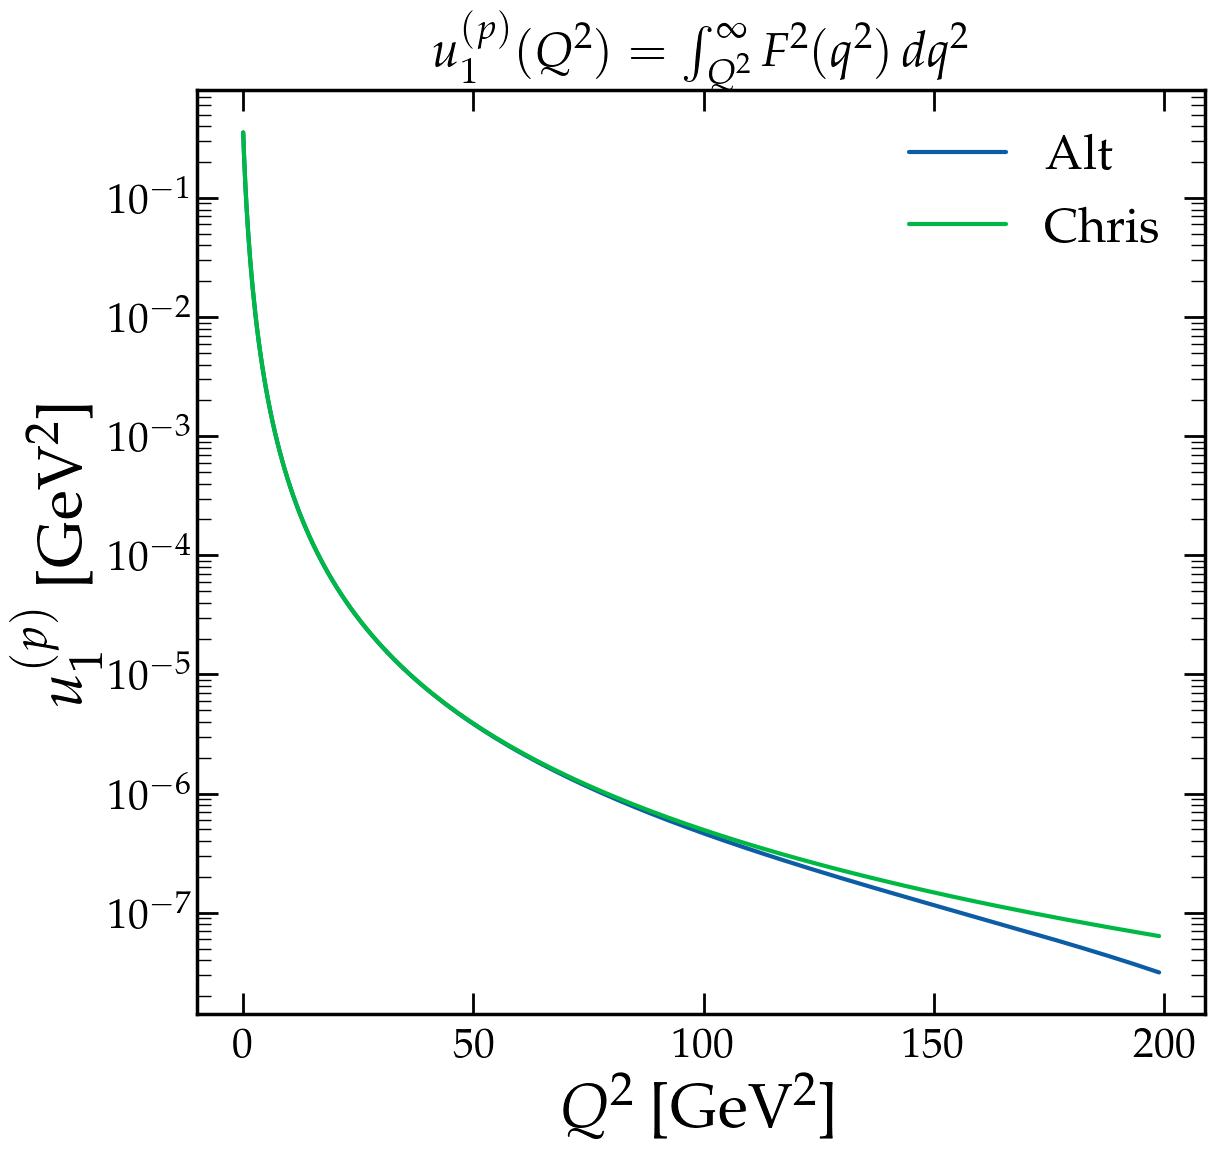

In [56]:
Q2Alt_proton = np.loadtxt('../csv/InterpolationList/Proton/InterpolationList_proton_Altmannshofer.txt', delimiter=',', usecols=0)
u1Alt_proton = np.loadtxt('../csv/InterpolationList/Proton/InterpolationList_proton_Altmannshofer.txt', delimiter=',', usecols=1)

def Proton(Q2):
    s1 = 4*Mproton**2*GpE_Alt(Q2)**2 / ( Q2 + 4*Mproton**2 )
    s2 = Q2 * ( GpM_Alt(Q2)**2 )/ ( Q2 + 4*Mproton**2 )
    return s1 + s2

def u1_Proton(Q2):
    main, _ = quad(Proton, Q2, np.infty)
    return main
u1_Proton = np.vectorize(u1_Proton)

fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Q2Alt_proton, u1Alt_proton, label='Alt')
ax.plot(Q2Alt_proton, u1_Proton(Q2Alt_proton), label='Chris')

ax.legend()
ax.set_title(r'$u_1^{(p)}(Q^2) = \int_{Q^2}^{\infty} F^2(q^2)\, dq^2$')
ax.set_ylabel(r'$u^{(p)}_1$ [GeV$^2$]')
ax.set_xlabel(r'$Q^2$ [GeV$^2$]')

ax.set_yscale('log')

plt.savefig('../Plots/Figures_PNG/proton_u1values.png', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PDF/proton_u1values.pdf', transparent=False, bbox_inches='tight')

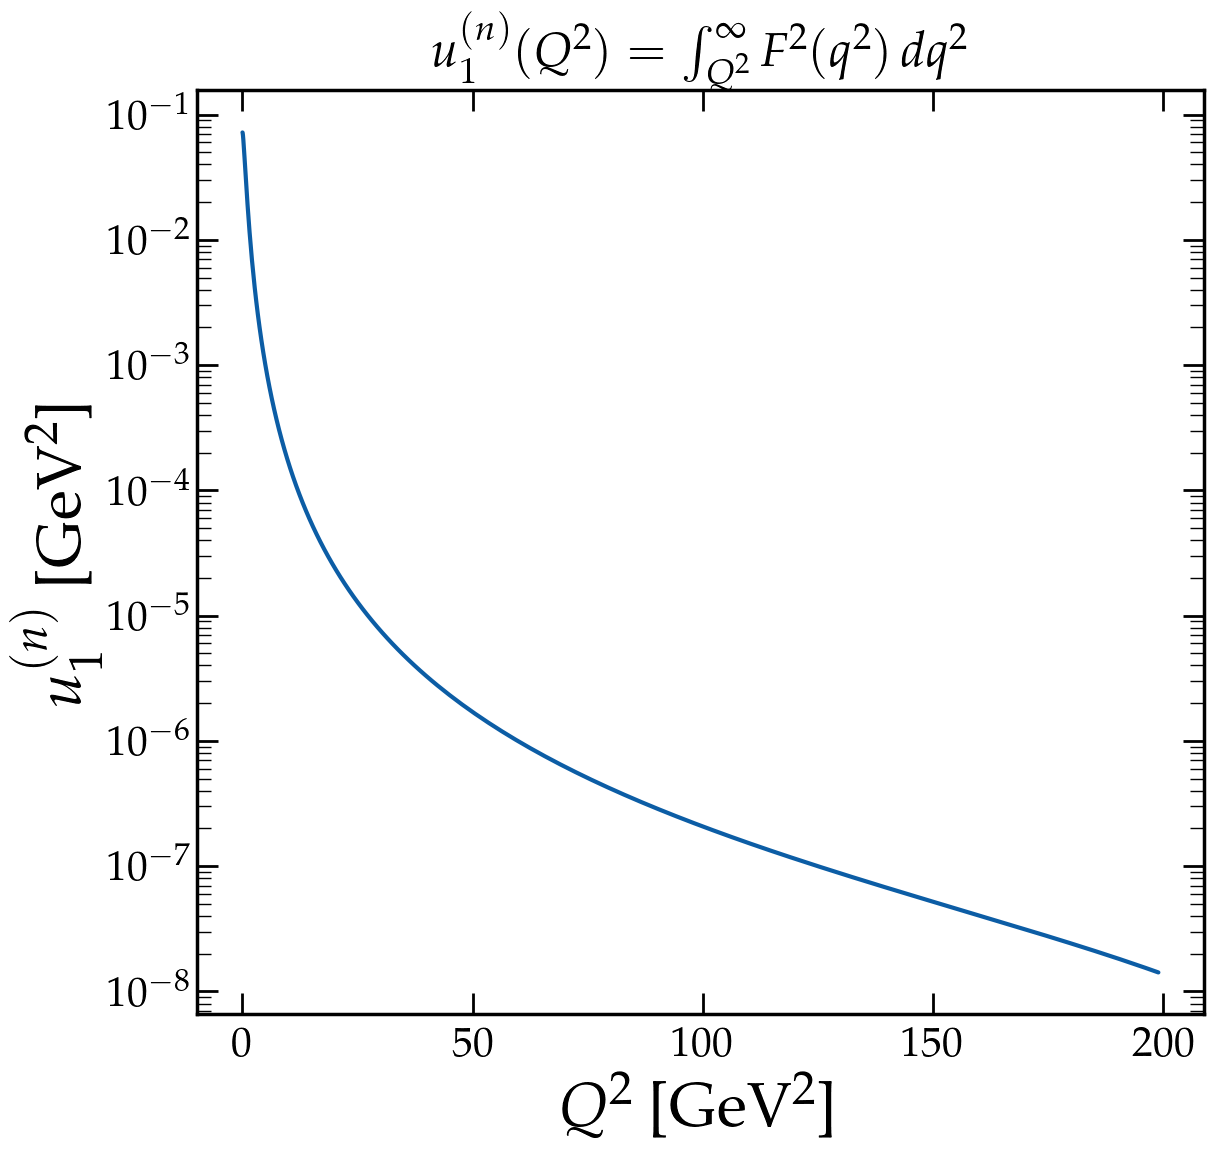

In [57]:
Q2Alt_neutron = np.loadtxt('../csv/InterpolationList/Neutron/InterpolationList_neutron_Altmannshofer.txt', delimiter=',', usecols=0)
u1Alt_neutron = np.loadtxt('../csv/InterpolationList/Neutron/InterpolationList_neutron_Altmannshofer.txt', delimiter=',', usecols=1)

fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Q2Alt_neutron, u1Alt_neutron)

ax.set_title(r'$u^{(n)}_1(Q^2) = \int_{Q^2}^{\infty} F^2(q^2)\, dq^2$')
ax.set_ylabel(r'$u^{(n)}_1$ [GeV$^2$]')
ax.set_xlabel(r'$Q^2$ [GeV$^2$]')

ax.set_yscale('log')

plt.savefig('../Plots/Figures_PNG/neutron_u1values.png', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PDF/neutron_u1values.pdf', transparent=False, bbox_inches='tight')